# Dimensionality Reduction — Category Recap

> **Goal:** project high-dimensional data $x \in \mathbb{R}^d$ into a low-dimensional space ($k = 2, 3, \dots$) that preserves something useful — variance, neighbourhood, or manifold structure.

This notebook ties together the three dimensionality-reduction notebooks.

| # | Algorithm | Preserves | Linear? |
|---|---|---|---|
| 24 | PCA (Principal Component Analysis) | global variance | ✅ |
| 25 | t-SNE | local neighbourhoods | ❌ |
| 26 | UMAP (Uniform Manifold Approximation and Projection) | local + some global | ❌ |

## Cheat-sheet — dimensionality reduction landscape

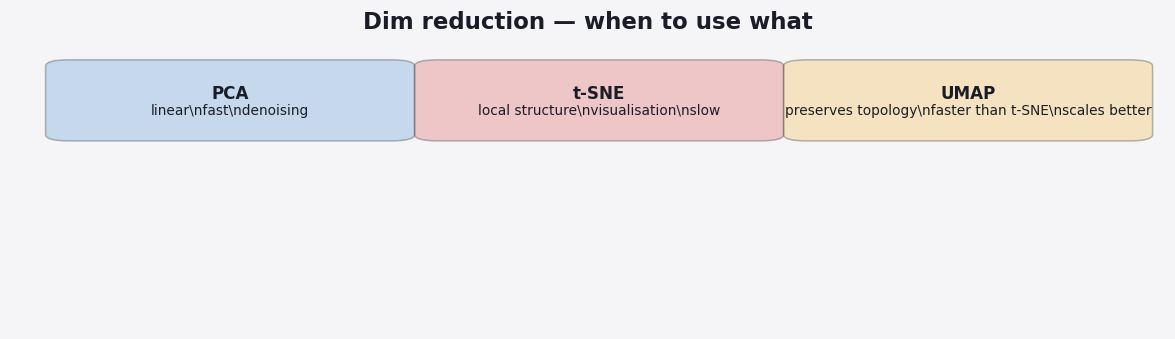

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis('off')
ax.text(0.5, 0.96, 'Dim reduction — when to use what', ha='center', fontsize=15, weight='bold')
items = [('PCA', 'linear\\nfast\\ndenoising'), ('t-SNE', 'local structure\\nvisualisation\\nslow'), ('UMAP', 'preserves topology\\nfaster than t-SNE\\nscales better')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Comparison

| Property | PCA | t-SNE | UMAP |
|---|---|---|---|
| Linear | ✅ | ❌ | ❌ |
| Preserves global distances | ✅ | ❌ | partial |
| Preserves local structure | partial | ✅ | ✅ |
| Has `transform` for new points | ✅ | ❌ | ✅ |
| Suitable as ML preprocessing | ✅ | ❌ visualisation only | partial |
| Scales to $n > 10^5$ | ✅ randomised | ❌ | ✅ |
| Deterministic | ✅ | ❌ | partial |
| Interpretable axes | ✅ loadings | ❌ | ❌ |

---
## Decision rule

In [ ]:
from IPython.display import SVG, display
_svg = """\
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 760 280" width="760" height="280"
     style="font-family:'DejaVu Sans',sans-serif;background:#f5f5f7;border-radius:8px;">
  <line x1="380" y1="57" x2="115" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="380" y1="57" x2="547" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="547" y1="142" x2="368" y2="195" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="547" y1="142" x2="638" y2="195" stroke="#c8ccd4" stroke-width="1.8"/>
  <text x="237" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="469" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <text x="447" y="168" text-anchor="end"   font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="598" y="168" text-anchor="start" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <rect x="155" y="15" width="450" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="380" y="40" text-anchor="middle" font-size="12" fill="#1a1d27">Structure linear (PCA directions)?</text>
  <rect x="10" y="100" width="210" height="42" rx="6" fill="#7ecba1" fill-opacity="0.25" stroke="#7ecba1" stroke-width="1.5"/>
  <text x="115" y="117" text-anchor="middle" font-size="12" fill="#1a1d27">PCA</text>
  <text x="115" y="133" text-anchor="middle" font-size="10" fill="#555b6e">(stop for ML preprocessing)</text>
  <rect x="378" y="100" width="338" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="547" y="125" text-anchor="middle" font-size="12" fill="#1a1d27">Visualisation only?</text>
  <rect x="218" y="195" width="300" height="42" rx="6" fill="#f4b942" fill-opacity="0.25" stroke="#f4b942" stroke-width="1.5"/>
  <text x="368" y="212" text-anchor="middle" font-size="12" fill="#1a1d27">UMAP (faster, global)</text>
  <text x="368" y="228" text-anchor="middle" font-size="11" fill="#1a1d27">or t-SNE (legacy)</text>
  <rect x="516" y="195" width="244" height="42" rx="6" fill="#c678dd" fill-opacity="0.25" stroke="#c678dd" stroke-width="1.5"/>
  <text x="638" y="212" text-anchor="middle" font-size="12" fill="#1a1d27">PCA &#x2192; Autoencoder</text>
  <text x="638" y="228" text-anchor="middle" font-size="10" fill="#555b6e">(never t-SNE/UMAP as features)</text>
</svg>"""
display(SVG(_svg))

I0000 00:00:1780225572.230138  352611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780225572.270603  352611 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780225574.283175  352611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


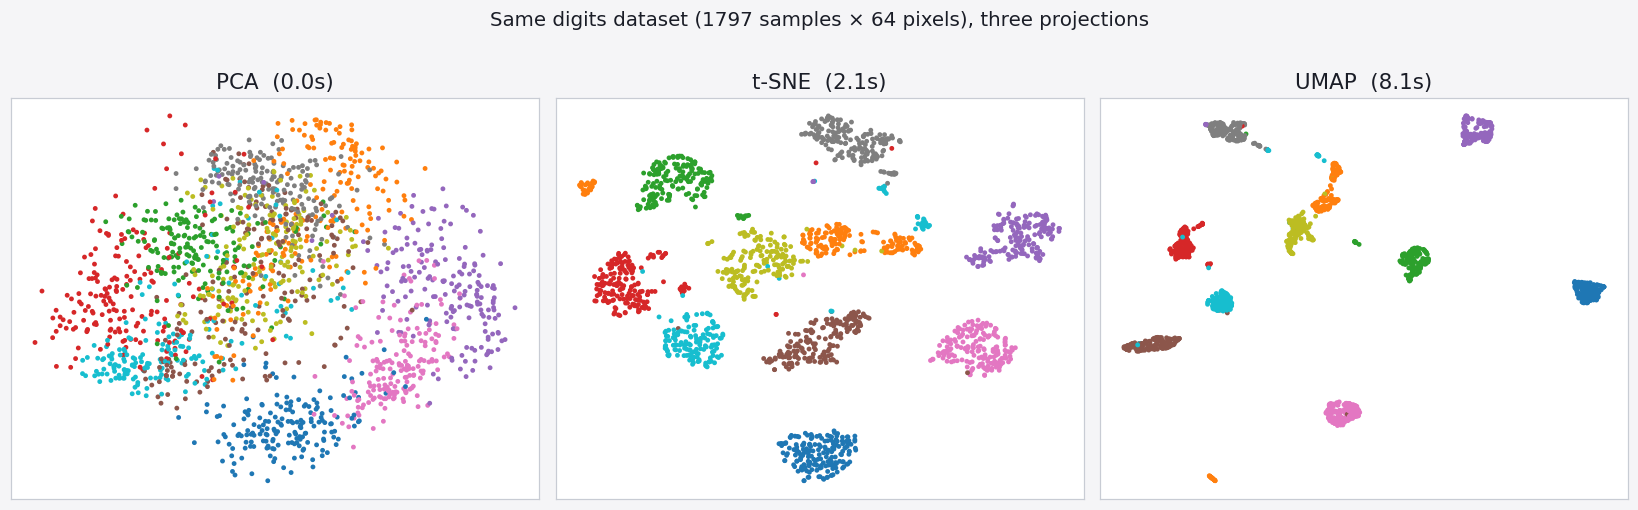

In [3]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time

X, y = load_digits(return_X_y=True)

t0 = time.time(); Z_pca  = PCA(n_components=2).fit_transform(X);  t_pca = time.time()-t0
t0 = time.time(); Z_tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=0).fit_transform(X); t_tsne = time.time()-t0
try:
    import umap
    t0 = time.time(); Z_umap = umap.UMAP(n_components=2, random_state=0).fit_transform(X); t_umap = time.time()-t0
    have_umap = True
except Exception as e:
    print('UMAP unavailable, skipping:', e)
    have_umap = False

n_panels = 3 if have_umap else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 4.5))
panels = [('PCA', Z_pca, t_pca), ('t-SNE', Z_tsne, t_tsne)]
if have_umap: panels.append(('UMAP', Z_umap, t_umap))

for ax, (name, Z, t) in zip(axes, panels):
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap='tab10', s=10, edgecolors='none')
    ax.set_title(f'{name}  ({t:.1f}s)')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Same digits dataset (1797 samples × 64 pixels), three projections', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


---
## Reading the panels

- **PCA** captures global variance — clusters of similar digits get pulled along the same axes, but several digits overlap heavily.
- **t-SNE** breaks the data into clear local clumps — within-cluster geometry is visible, but the **distances between clumps are meaningless**.
- **UMAP** strikes a middle ground: tight within-cluster structure *and* roughly preserved inter-cluster geometry, in a fraction of t-SNE's runtime.

> Lesson: **PCA is for features**, t-SNE/UMAP are for **eyeballs**. Don't mix them up.
